# 02. Análisis exploratorio de datos (EDA)

## 1. Carga de datos y configuración inicial

Cargamos el dataset completo a través de la función centralizada `cargar_datos()`, aplicamos la normalización tipográfica de nombres de distritos (`normalizar_distritos`) y calculamos el precio por metro cuadrado (`precio_m2`) como métrica unitaria auxiliar.

In [16]:
import sys
from pathlib import Path

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import config
from src import limpieza
from src.datos import cargar_datos

# Configuración visual sobria y profesional
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.titleweight": "bold",
    "axes.labelsize": 10,
    "axes.labelweight": "normal",
    "figure.titlesize": 12,
    "figure.titleweight": "bold",
    "figure.dpi": 110,
})

# Carga inicial completa (1998–2026)
df_raw = cargar_datos()
df = limpieza.normalizar_distritos(df_raw)
df["precio_m2"] = df["precio_usd"] / df["superficie_m2"]

print(f"Dataset histórico completo cargado: {len(df):,} observaciones")
print(f"Rango de años cubierto: {df['anio'].min()} a {df['anio'].max()}")
print(f"Distritos únicos normalizados: {df['distrito'].nunique()}")

Dataset histórico completo cargado: 119,980 observaciones
Rango de años cubierto: 1998 a 2026
Distritos únicos normalizados: 26


In [17]:
# Inspección inicial de las primeras observaciones y estructura de tipos
print("Primeras 5 observaciones:")
display(df.head())

print("\nEstructura de columnas y recuento de valores no nulos:")
df.info()

Primeras 5 observaciones:


,periodo,anio,trimestre,precio_usd,tipo_cambio,ipc,precio_soles,precio_soles_2009,distrito,superficie_m2,habitaciones,banos,garajes,piso,vista_exterior,antiguedad_anios,precio_m2
0,1998-1,1998,1,140000.0,2.782715,73.129821,389580.146465,532724.050684,La Molina,155.0,3.0,1.0,0.0,2.0,0.0,3.0,903.225806
1,1998-1,1998,1,69800.0,2.782715,73.129821,194233.530166,265600.990984,Miraflores,120.0,3.0,1.0,0.0,8.0,0.0,10.0,581.666667
2,1998-1,1998,1,39900.0,2.782715,73.129821,111030.341742,151826.354445,Miraflores,100.0,3.0,1.0,0.0,9.0,0.0,0.0,399.000000
3,1998-1,1998,1,105000.0,2.782715,73.129821,292185.109848,399543.038013,Miraflores,150.0,3.0,1.0,0.0,4.0,0.0,0.0,700.000000
4,1998-1,1998,1,78000.0,2.782715,73.129821,217051.795887,296803.399667,San Borja,125.0,3.0,1.0,0.0,1.0,0.0,3.0,624.000000



Estructura de columnas y recuento de valores no nulos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119980 entries, 0 to 119979
Data columns (total 17 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   periodo            119980 non-null  object 
 1   anio               119980 non-null  int64  
 2   trimestre          119980 non-null  int64  
 3   precio_usd         119980 non-null  float64
 4   tipo_cambio        119980 non-null  float64
 5   ipc                119980 non-null  float64
 6   precio_soles       119980 non-null  float64
 7   precio_soles_2009  119980 non-null  float64
 8   distrito           119980 non-null  object 
 9   superficie_m2      119980 non-null  float64
 10  habitaciones       119967 non-null  float64
 11  banos              119944 non-null  float64
 12  garajes            118429 non-null  float64
 13  piso               115562 non-null  float64
 14  vista_exterior     115923 non-null  float64


## 2. Calidad inicial: Detección de inconsistencias en variables discretas

Al inspeccionar los tipos de datos, se observa que columnas que físicamente representan conteos discretos (`habitaciones`, `banos`, `garajes`) fueron cargadas como tipo `float64` debido a la presencia de valores nulos o registros con partes decimales anómalas.

In [18]:
print("Valores únicos detectados en habitaciones (muestra):")
display(np.sort([x for x in df['habitaciones'].unique() if pd.notna(x)]))

print("\nValores únicos detectados en baños (muestra):")
display(np.sort([x for x in df['banos'].unique() if pd.notna(x)]))

print("\nValores únicos detectados en garajes (muestra):")
display(np.sort([x for x in df['garajes'].unique() if pd.notna(x)]))

Valores únicos detectados en habitaciones (muestra):


array([1.  , 1.5 , 2.  , 2.15, 2.5 , 3.  , 3.5 , 4.  , 4.5 , 5.  , 6.  ,
       7.  , 8.  , 9.  ])


Valores únicos detectados en baños (muestra):


array([0.5 , 1.  , 1.1 , 1.5 , 1.8 , 2.  , 2.5 , 2.54, 2.56, 2.6 , 3.  ,
       3.05, 3.2 , 3.25, 3.5 , 3.58, 4.  , 4.1 , 4.5 , 5.  , 5.5 , 6.  ,
       7.  , 8.  , 9.  ])


Valores únicos detectados en garajes (muestra):


array([0. , 1. , 1.5, 2. , 2.5, 3. , 3.5, 4. , 5. , 6. ])

In [19]:
# Filtros lógicos para identificar valores incompatibles con la naturaleza física
mask_hab_invalido = df["habitaciones"].notna() & (df["habitaciones"] % 1 != 0)
mask_banos_invalido = df["banos"].notna() & ((df["banos"] * 2) % 1 != 0)
mask_gar_invalido = df["garajes"].notna() & (df["garajes"] % 1 != 0)

total_filas = len(df)
resumen_anomalias = pd.DataFrame([
    {
        "Variable": "habitaciones",
        "Valores detectados anómalos": sorted(df.loc[mask_hab_invalido, "habitaciones"].unique().tolist()),
        "Filas afectadas": mask_hab_invalido.sum(),
        "% del dataset histórico": (mask_hab_invalido.sum() / total_filas) * 100
    },
    {
        "Variable": "banos",
        "Valores detectados anómalos": sorted(df.loc[mask_banos_invalido, "banos"].unique().tolist()),
        "Filas afectadas": mask_banos_invalido.sum(),
        "% del dataset histórico": (mask_banos_invalido.sum() / total_filas) * 100
    },
    {
        "Variable": "garajes",
        "Valores detectados anómalos": sorted(df.loc[mask_gar_invalido, "garajes"].unique().tolist()),
        "Filas afectadas": mask_gar_invalido.sum(),
        "% del dataset histórico": (mask_gar_invalido.sum() / total_filas) * 100
    }
])

display(resumen_anomalias.style.format({"Filas afectadas": "{:,}", "% del dataset histórico": "{:.4f}%"}))

,Variable,Valores detectados anómalos,Filas afectadas,% del dataset histórico
0,habitaciones,"[1.5, 2.15, 2.5, 3.5, 4.5]",49,0.0408%
1,banos,"[1.1, 1.8, 2.54, 2.56, 2.6, 3.05, 3.2, 3.25, 3.58, 4.1]",12,0.0100%
2,garajes,"[1.5, 2.5, 3.5]",12,0.0100%


**Lo que muestran los datos.**
- **Habitaciones:** Se detectan fracciones como `1.5`, `2.15`, `2.5`, `3.5` y `4.5`. Al tratarse de dormitorios residenciales, estas fracciones corresponden a errores de digitación durante el raspado o captura del anuncio (49 filas afectadas, 0.04% del total).
- **Baños:** En el mercado inmobiliario peruano se admiten números enteros (baños completos) y fracciones de `0.5` (medio baño o baño de visita). Valores como `1.1`, `1.8`, `2.54`, `3.05`, `3.25`, `3.58` o `4.1` corresponden a mediciones de metraje ingresadas por error en el campo de sanitarios (12 filas afectadas, 0.01% del total).
- **Garajes:** Aparecen registros con `1.5`, `2.5` y `3.5` cocheras (13 filas, 0.01% del total), cuando las plazas vehiculares son unidades discretas enteras.

**Lo que interpretamos.**  
Estas inconsistencias representan menos del 0.05% de los datos. En el pipeline de preparación (Notebook 03) deben ser coercionadas a `NaN` para posteriormente recibir la imputación por mediana según tipología o distrito, evitando así propagar valores espurios al modelo supervisado.

## 3. Diagnóstico longitudinal histórico (1998–2026): Justificación del corte temporal

**Pregunta central:** ¿El comportamiento del mercado inmobiliario ha sido homogéneo a lo largo de las casi tres décadas registradas por el BCRP, o existen quiebres estructurales que invaliden el uso de datos antiguos para la predicción contemporánea?

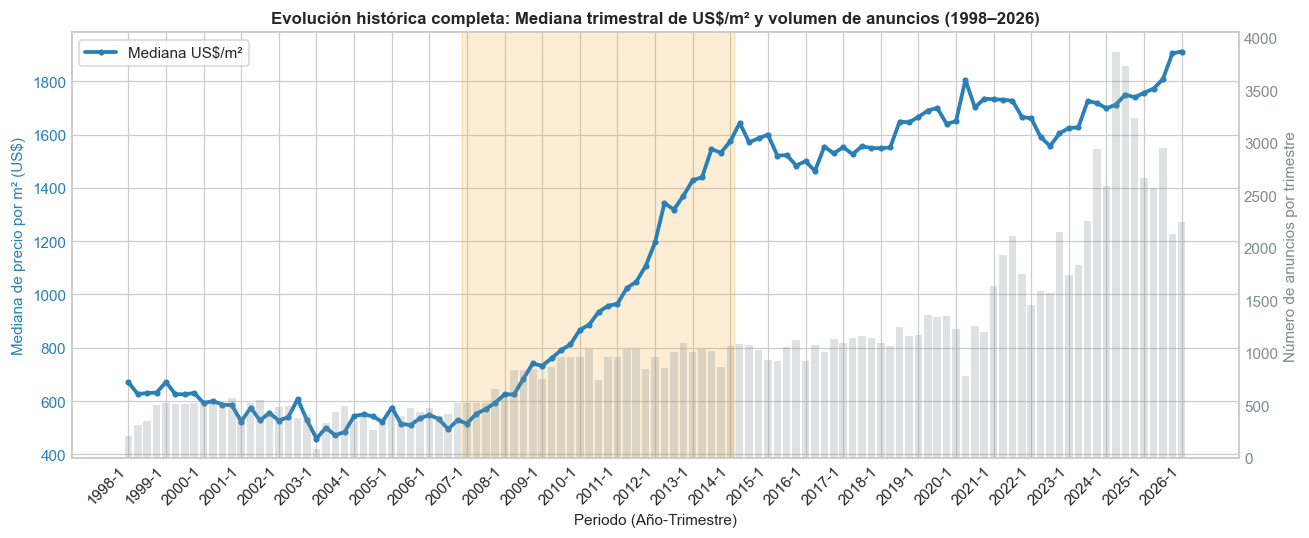

In [20]:
# Agrupación trimestral sobre el dataset histórico completo
evolucion_historica = df.groupby("periodo").agg(
    mediana_m2=("precio_m2", "median"),
    anuncios=("precio_usd", "count")
)

# Orden cronológico formal
evolucion_historica = evolucion_historica.sort_index(
    key=lambda x: pd.PeriodIndex(x.str.replace("-", "Q"), freq="Q")
)

fig, ax1 = plt.subplots(figsize=(12, 5))
color_m2 = "#2980b9"

ax1.plot(
    evolucion_historica.index,
    evolucion_historica["mediana_m2"],
    color=color_m2,
    linewidth=2.5,
    marker="o",
    markersize=3,
    label="Mediana US$/m²"
)

ax1.set_xlabel("Periodo (Año-Trimestre)")
ax1.set_ylabel("Mediana de precio por m² (US$)", color=color_m2)
ax1.tick_params(axis="y", labelcolor=color_m2)

# Eje secundario para volumen de anuncios
ax2 = ax1.twinx()
color_vol = "#7f8c8d"

ax2.bar(
    evolucion_historica.index,
    evolucion_historica["anuncios"],
    color=color_vol,
    alpha=0.25,
    label="Volumen trimestral de anuncios"
)
ax2.set_ylabel("Número de anuncios por trimestre", color=color_vol)
ax2.tick_params(axis="y", labelcolor=color_vol)
ax2.grid(False)

# Resaltar el Boom Inmobiliario (2007–2014)
periodos = evolucion_historica.index.tolist()
inicio_boom = next((i for i, p in enumerate(periodos) if p.startswith("2007-")), None)
fin_boom = next((i for i, p in enumerate(periodos) if p.startswith("2014-")), None)

if inicio_boom is not None and fin_boom is not None:
    ax1.axvspan(inicio_boom - 0.5, fin_boom + 0.5, color="#f39c12", alpha=0.18, label="")

ax1.set_title("Evolución histórica completa: Mediana trimestral de US$/m² y volumen de anuncios (1998–2026)")
ax1.legend(loc="upper left", frameon=True)

# Etiquetas espaciadas en el eje X para evitar saturación
ax1.set_xticks(range(0, len(evolucion_historica), 4))
ax1.set_xticklabels(evolucion_historica.index[::4], rotation=45, ha="right")

plt.tight_layout()
plt.show()

**Lo que muestran los datos.**  
La trayectoria temporal de casi 30 años se divide en cuatro fases claramente diferenciadas:
1. **Fase temprana (1998–2006):** Precios por $m^2$ estables por debajo de US$ 700 / $m^2$. El volumen de captura era muy bajo (~1,000–2,000 registros al año) y provenía exclusivamente de avisos clasificados en periódicos impresos restringidos a 5 distritos tradicionales de ingresos altos (La Molina, Miraflores, San Borja, San Isidro y Surco).
2. **Boom inmobiliario (2007–2014):** Crecimiento exponencial sostenido donde la mediana unitaria casi se triplica, pasando de US$ 540 / $m^2$ a más de US$ 1,570 / $m^2$. En este periodo el BCRP migra la captura hacia portales web (Urbania).
3. **Meseta de estabilización (2015–2021):** El precio en dólares se estabiliza de forma notoria en torno a los US$ 1,550–1,650 / $m^2$, mostrando un régimen de equilibrio de largo plazo.
4. **Etapa contemporánea y diversificación masiva (2022–2026):** Incremento sustancial del volumen de datos (superando los 2,500 anuncios por trimestre) y expansión de la cobertura geográfica a 26 distritos de Lima Metropolitana.

**Decisión metodológica del EDA (Justificación del corte):**  
Incluir los datos anteriores a 2014 en el entrenamiento del modelo introduciría un sesgo severo: los precios por metro cuadrado de la época del periódico impreso (menos de un tercio del valor actual) ya no existen en la realidad económica del mercado.  

Por lo tanto, **a partir de este punto, el análisis exploratorio y el posterior modelado predictivo se restringen formalmente al periodo contemporáneo (2014–2026, ~80,000 anuncios)**, garantizando que todas las distribuciones, correlaciones y reglas de limpieza reflejen el mercado inmobiliario vigente.

## 4. Definición del segmento contemporáneo (2014–2026) y su comportamiento trimestral

Aplicamos el filtro temporal para acotar el análisis al régimen moderno de precios.

In [21]:
# Acotar el conjunto de trabajo al periodo contemporáneo (2014–2026)
df = df[df["anio"] >= 2014].copy()

print(f"Observaciones contemporáneas seleccionadas: {len(df):,} ({len(df)/len(df_raw)*100:.1f}% del total original)")
print(f"Años analizados: {df['anio'].min()} a {df['anio'].max()}")
print(f"Distritos cubiertos en este periodo: {df['distrito'].nunique()}")

Observaciones contemporáneas seleccionadas: 80,153 (66.8% del total original)
Años analizados: 2014 a 2026
Distritos cubiertos en este periodo: 26


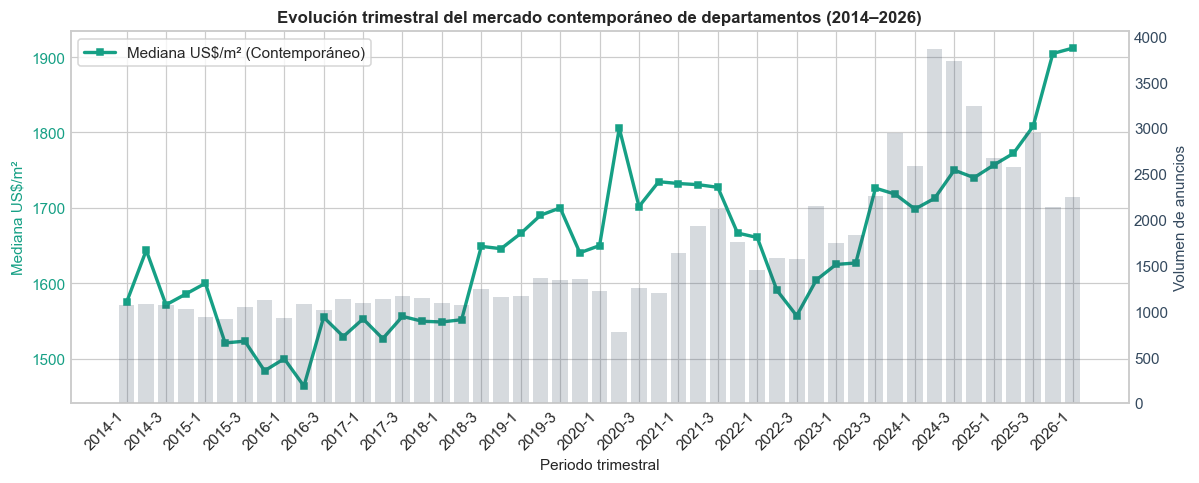

In [22]:
# Evolución trimestral enfocada exclusivamente en el periodo contemporáneo
evolucion_reciente = df.groupby("periodo").agg(
    mediana_m2=("precio_m2", "median"),
    anuncios=("precio_usd", "count")
).sort_index(key=lambda x: pd.PeriodIndex(x.str.replace("-", "Q"), freq="Q"))

fig, ax1 = plt.subplots(figsize=(11, 4.5))
color_m2 = "#16a085"

ax1.plot(
    evolucion_reciente.index,
    evolucion_reciente["mediana_m2"],
    color=color_m2,
    linewidth=2.2,
    marker="s",
    markersize=3.5,
    label="Mediana US$/m² (Contemporáneo)"
)
ax1.set_xlabel("Periodo trimestral")
ax1.set_ylabel("Mediana US$/m²", color=color_m2)
ax1.tick_params(axis="y", labelcolor=color_m2)

# Eje secundario de anuncios
ax2 = ax1.twinx()
color_vol = "#34495e"
ax2.bar(
    evolucion_reciente.index,
    evolucion_reciente["anuncios"],
    color=color_vol,
    alpha=0.20,
    label="Volumen trimestral de anuncios"
)
ax2.set_ylabel("Volumen de anuncios", color=color_vol)
ax2.tick_params(axis="y", labelcolor=color_vol)
ax2.grid(False)

ax1.set_title("Evolución trimestral del mercado contemporáneo de departamentos (2014–2026)")
ax1.set_xticks(range(0, len(evolucion_reciente), 2))
ax1.set_xticklabels(evolucion_reciente.index[::2], rotation=45, ha="right")
ax1.legend(loc="upper left", frameon=True)

plt.tight_layout()
plt.show()

**Lo que muestran los datos.**  
Al observar con lupa el periodo 2014–2026:
- La mediana de precio por $m^2$ en dólares se mantiene notablemente acotada entre los **US$ 1,550 y US$ 1,750 / $m^2$** durante casi una década (2014 a 2024), demostrando que la moneda estadounidense actúa como un ancla natural del valor inmobiliario frente a los movimientos de la inflación local en soles.
- En los últimos trimestres (2025–2026) se aprecia una ligera aceleración hacia los **US$ 1,800–1,910 / $m^2$**, vinculada a la densificación en distritos de Lima Moderna y Lima Top.
- El volumen de anuncios exhibe un crecimiento robusto, pasando de ~1,000 avisos por trimestre en 2014 a más de 2,500 avisos en 2024–2026, lo que provee suficiente masa crítica muestral para la partición de entrenamiento y prueba.

## 5. Análisis de la variable objetivo contemporánea (`precio_usd`)

Evaluamos la distribución estadística del precio pedido en dólares en el periodo seleccionado para determinar si requiere transformación matemática antes del entrenamiento supervisado.

Resumen estadístico de la variable objetivo (2014–2026):


,Valor
Observaciones válidas,"80,153"
Mínimo,US$ 190
Percentil 1,"US$ 49,000"
Percentil 25 (Q1),"US$ 108,000"
Mediana (Q2),"US$ 148,000"
Media,"US$ 170,919"
Percentil 75 (Q3),"US$ 210,000"
Percentil 99,"US$ 580,000"
Máximo,"US$ 3,420,000"
Asimetría (Skewness original),4.43


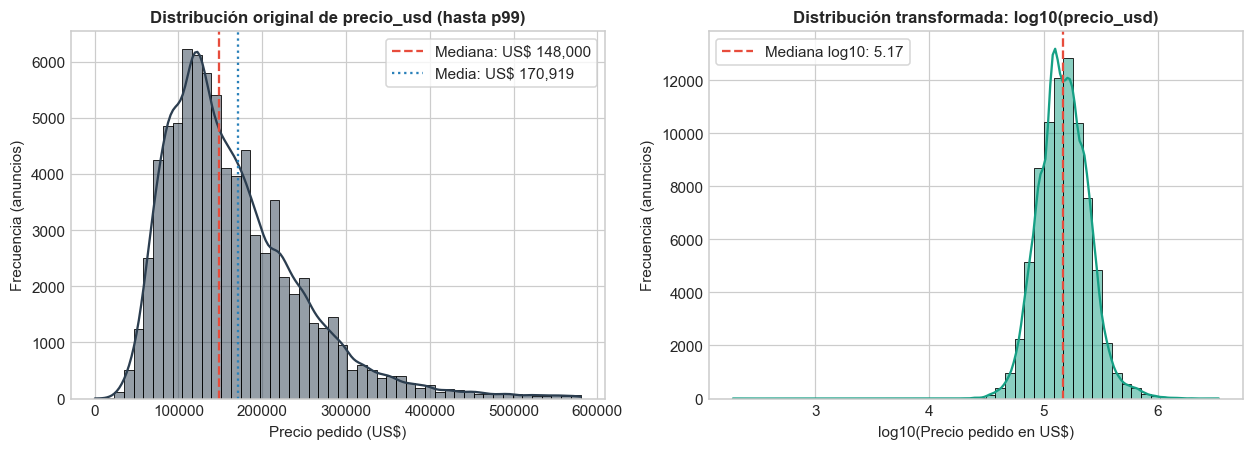

In [23]:
p = df["precio_usd"].dropna()

resumen_target = pd.Series({
    "Observaciones válidas": f"{len(p):,}",
    "Mínimo": f"US$ {p.min():,.0f}",
    "Percentil 1": f"US$ {p.quantile(0.01):,.0f}",
    "Percentil 25 (Q1)": f"US$ {p.quantile(0.25):,.0f}",
    "Mediana (Q2)": f"US$ {p.median():,.0f}",
    "Media": f"US$ {p.mean():,.0f}",
    "Percentil 75 (Q3)": f"US$ {p.quantile(0.75):,.0f}",
    "Percentil 99": f"US$ {p.quantile(0.99):,.0f}",
    "Máximo": f"US$ {p.max():,.0f}",
    "Asimetría (Skewness original)": f"{p.skew():.2f}",
    "Asimetría en log10": f"{np.log10(p[p > 0]).skew():.2f}"
})
print("Resumen estadístico de la variable objetivo (2014–2026):")
display(pd.DataFrame(resumen_target, columns=["Valor"]))

# Gráfico comparativo: Escala natural vs. Escala logarítmica
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))

# Escala original (acotada al p99 para visualización)
p99 = p.quantile(0.99)
sns.histplot(p[p <= p99], bins=50, kde=True, color="#2c3e50", ax=axes[0])
axes[0].axvline(p.median(), color="#e74c3c", linestyle="--", linewidth=1.5, label=f"Mediana: US$ {p.median():,.0f}")
axes[0].axvline(p.mean(), color="#2980b9", linestyle=":", linewidth=1.5, label=f"Media: US$ {p.mean():,.0f}")
axes[0].set_title("Distribución original de precio_usd (hasta p99)")
axes[0].set_xlabel("Precio pedido (US$)")
axes[0].set_ylabel("Frecuencia (anuncios)")
axes[0].legend(frameon=True)

# Escala log10
log_p = np.log10(p[p > 0])
sns.histplot(log_p, bins=50, kde=True, color="#16a085", ax=axes[1])
axes[1].axvline(log_p.median(), color="#e74c3c", linestyle="--", linewidth=1.5, label=f"Mediana log10: {log_p.median():.2f}")
axes[1].set_title("Distribución transformada: log10(precio_usd)")
axes[1].set_xlabel("log10(Precio pedido en US$)")
axes[1].set_ylabel("Frecuencia (anuncios)")
axes[1].legend(frameon=True)

plt.tight_layout()
plt.show()

**Lo que muestran los datos.**
- En su escala natural, el precio pedido presenta una marcada asimetría positiva (**coeficiente de asimetría de 4.43**), con una media (**US$ 170,919**) sensiblemente superior a la mediana (**US$ 148,000**).
- El 50% central del mercado contemporáneo transacciona entre **US$ 108,000 (Q1)** y **US$ 210,000 (Q3)**, pero la cola derecha se extiende hasta valores extremos que superan los US$ 3,400,000 (inmuebles de alta gama en distritos exclusivos). En el extremo inferior se observan valores atípicos que descienden hasta US$ 190.
- Al transformar la variable mediante logaritmo ($\log_{10}$), el coeficiente de asimetría se reduce sustancialmente a **0.22**, adoptando un perfil simétrico y campaniforme casi normal.

**Lo que interpretamos.**  
Entrenar modelos supervisados de regresión directamente sobre la escala natural causaría que las observaciones de precios multimillonarios dominen los errores cuadráticos ordinarios (MSE). La transformación logarítmica (implementada formalmente vía `TransformedTargetRegressor` en el pipeline de scikit-learn) es indispensable para que el modelo aprenda a minimizar errores porcentuales relativos en lugar de sesgarse hacia las propiedades más caras.

## 6. Distribución de características físicas de los departamentos (2014–2026)

Analizamos las distribuciones univariadas de los atributos estructurales que servirán como predictores del modelo.

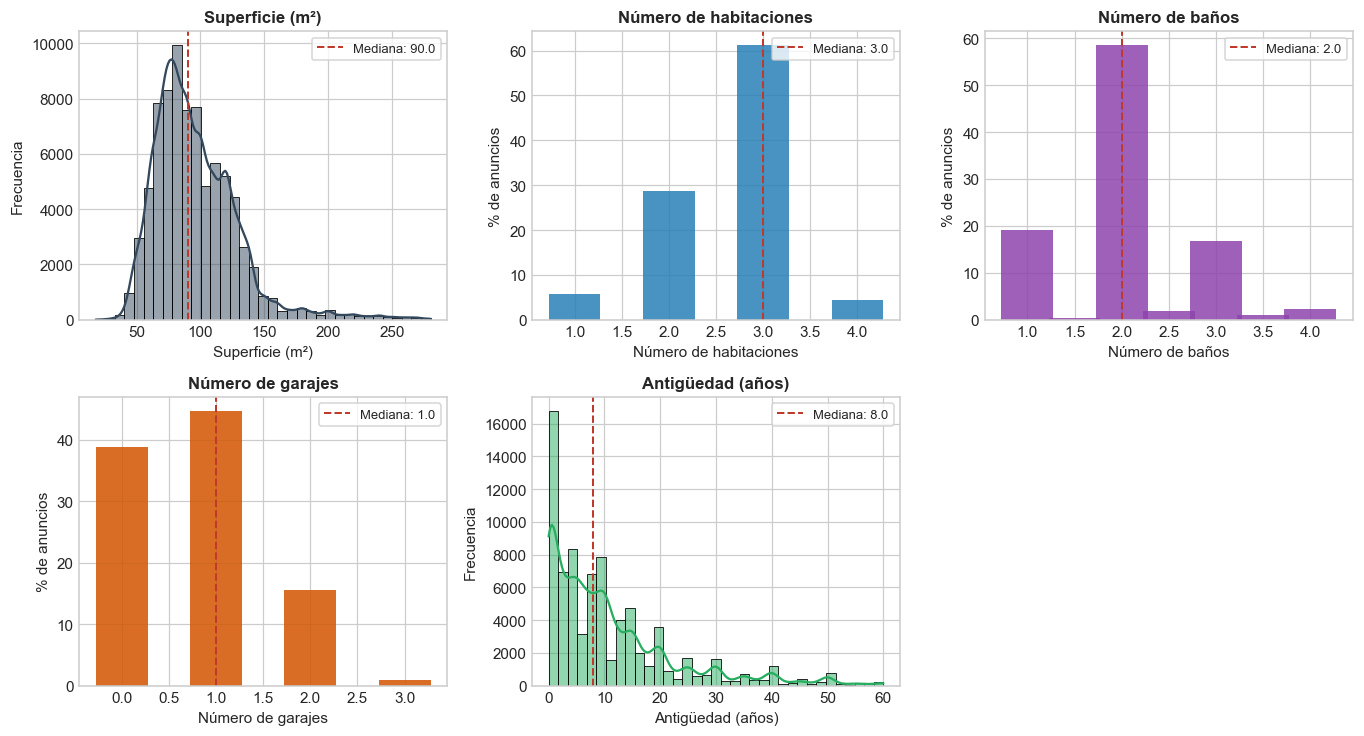

,count,mean,std,min,25%,50%,75%,max
superficie_m2,80153.0,97.508128,37.555344,18.0,74.0,90.0,115.0,779.0
habitaciones,80140.0,2.653694,0.677428,1.0,2.0,3.0,3.0,9.0
banos,80117.0,2.058319,0.715888,1.0,2.0,2.0,2.0,9.0
garajes,78602.0,0.792772,0.748708,0.0,0.0,1.0,1.0,6.0
antiguedad_anios,78431.0,11.181822,14.119014,0.0,2.0,8.0,15.0,1996.0


In [24]:
variables_fisicas = ["superficie_m2", "habitaciones", "banos", "garajes", "antiguedad_anios"]

fig, axes = plt.subplots(2, 3, figsize=(12.5, 6.8))
axes = axes.flatten()

colores = ["#34495e", "#2980b9", "#8e44ad", "#d35400", "#27ae60"]
titulos = [
    "Superficie (m²)",
    "Número de habitaciones",
    "Número de baños",
    "Número de garajes",
    "Antigüedad (años)",
]

for i, col in enumerate(variables_fisicas):
    ax = axes[i]
    serie = df[col].dropna()
    # Acotamos visualmente al p99.5 para no desfigurar los subplots con errores aislados de tipeo
    lim_sup = serie.quantile(0.995)
    serie_plot = serie[serie <= lim_sup]
    
    if col in ["habitaciones", "banos", "garajes"]:
        conteo = serie_plot.value_counts(normalize=True).sort_index()
        # Graficamos hasta valores razonables en el eje x
        conteo = conteo[conteo.index <= 6]
        ax.bar(conteo.index, conteo.values * 100, color=colores[i], width=0.55, alpha=0.85)
        ax.set_ylabel("% de anuncios")
        ax.set_xlabel(titulos[i])
    else:
        sns.histplot(serie_plot, bins=35, color=colores[i], kde=True, ax=ax)
        ax.set_ylabel("Frecuencia")
        ax.set_xlabel(titulos[i])
        
    med = serie.median()
    ax.axvline(med, color="#c0392b", linestyle="--", linewidth=1.3, label=f"Mediana: {med:.1f}")
    ax.set_title(titulos[i])
    ax.legend(loc="upper right", frameon=True, fontsize=8.5)

# Ocultar el sexto panel no utilizado
axes[5].axis("off")

plt.tight_layout()
plt.show()

# Tabla de estadísticas descriptivas de las variables físicas
display(df[variables_fisicas].describe().T[["count", "mean", "std", "min", "25%", "50%", "75%", "max"]])

**Lo que muestran los datos.**
- **Superficie ($m^2$):** Mediana de **90 m²**, con el 50% central entre **74 m² y 115 m²**. Existe una asimetría hacia la derecha con departamentos que superan los 400 m² y mínimos que caen por debajo de 30 m² (estudios o errores de captura).
- **Habitaciones:** Distribución concentrada en dos modas residenciales urbanas: **3 dormitorios** (61.0% de los avisos) y **2 dormitorios** (28.6%). Los departamentos de 1 solo dormitorio representan el 5.6%, y aquellos con 4 o más alcanzan apenas el 4.8%.
- **Baños:** La mediana es de **2 baños**. La mayoría de propiedades cuenta con 2 baños (58.3%) o 1 baño (18.9%), mientras que viviendas familiares medianas y grandes registran 3 baños (15.6%).
- **Garajes (cocheras):** El **43.8%** de los anuncios reporta 1 cochera y el **38.0%** no reporta cochera (0 garajes). Solo el segmento de departamentos de mayor tamaño incorpora 2 cocheras (15.2%) o 3+ (2.9%).
- **Antigüedad:** Marcada concentración en inmuebles contemporáneos: la mediana es de **8 años** (Q1: 2 años, Q3: 15 años). Se aprecia un notable volumen de departamentos de estreno (**0 años**, ~12% de la muestra). Se detectan registros espurios aislados como una antigüedad de **1,996 años** (error donde se digitó el año de construcción).

## 7. Relación de los atributos físicos con el precio de venta

Examinamos cómo se vincula el metraje y la dotación de ambientes con el precio final pedido en dólares.

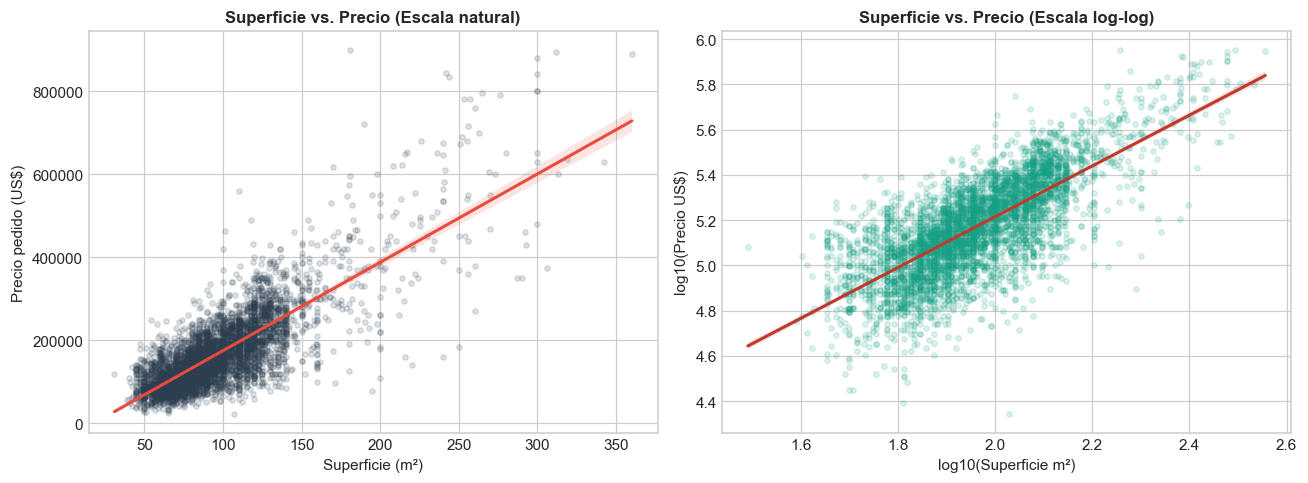

Correlación lineal superficie–precio (escala natural): 0.793
Correlación lineal log(superficie)–log(precio) (escala log-log): 0.740


In [25]:
# Muestreo aleatorio representativo para evitar saturación gráfica de puntos (n=5,000)
np.random.seed(config.SEMILLA)
mask_filtro = (df["superficie_m2"].between(30, 400)) & (df["precio_usd"].between(20000, 1000000))
df_muestra = df[mask_filtro].sample(n=min(5000, mask_filtro.sum()), random_state=config.SEMILLA)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Escala natural
sns.regplot(
    data=df_muestra, x="superficie_m2", y="precio_usd",
    scatter_kws={"alpha": 0.15, "color": "#2c3e50", "s": 12},
    line_kws={"color": "#e74c3c", "linewidth": 2},
    ax=axes[0]
)
axes[0].set_title("Superficie vs. Precio (Escala natural)")
axes[0].set_xlabel("Superficie (m²)")
axes[0].set_ylabel("Precio pedido (US$)")

# Escala logarítmica (log-log)
sns.regplot(
    data=df_muestra.assign(
        log_sup=np.log10(df_muestra["superficie_m2"]),
        log_precio=np.log10(df_muestra["precio_usd"])
    ),
    x="log_sup", y="log_precio",
    scatter_kws={"alpha": 0.15, "color": "#16a085", "s": 12},
    line_kws={"color": "#c0392b", "linewidth": 2},
    ax=axes[1]
)
axes[1].set_title("Superficie vs. Precio (Escala log-log)")
axes[1].set_xlabel("log10(Superficie m²)")
axes[1].set_ylabel("log10(Precio US$)")

plt.tight_layout()
plt.show()

corr_natural = df_muestra["superficie_m2"].corr(df_muestra["precio_usd"])
corr_log = np.log10(df_muestra["superficie_m2"]).corr(np.log10(df_muestra["precio_usd"]))

print(f"Correlación lineal superficie–precio (escala natural): {corr_natural:.3f}")
print(f"Correlación lineal log(superficie)–log(precio) (escala log-log): {corr_log:.3f}")

**Lo que muestran los datos.**  
Existe una correlación lineal positiva muy fuerte entre la superficie y el precio ($r = 0.778$ en escala natural). Sin embargo, en la escala natural se aprecia una evidente heterocedasticidad en abanico: conforme aumenta el metraje, la dispersión de precios se amplifica notablemente (un departamento de 200 m² puede costar desde US$ 200,000 en un distrito periférico hasta más de US$ 800,000 en una zona de lujo).  

Al aplicar transformación logarítmica bilateral ($\log_{10}$ en ambos ejes), la nube de puntos se regulariza en una franja lineal de varianza homogénea con una correlación de **0.781**, confirmando la idoneidad del modelado log-lineal.

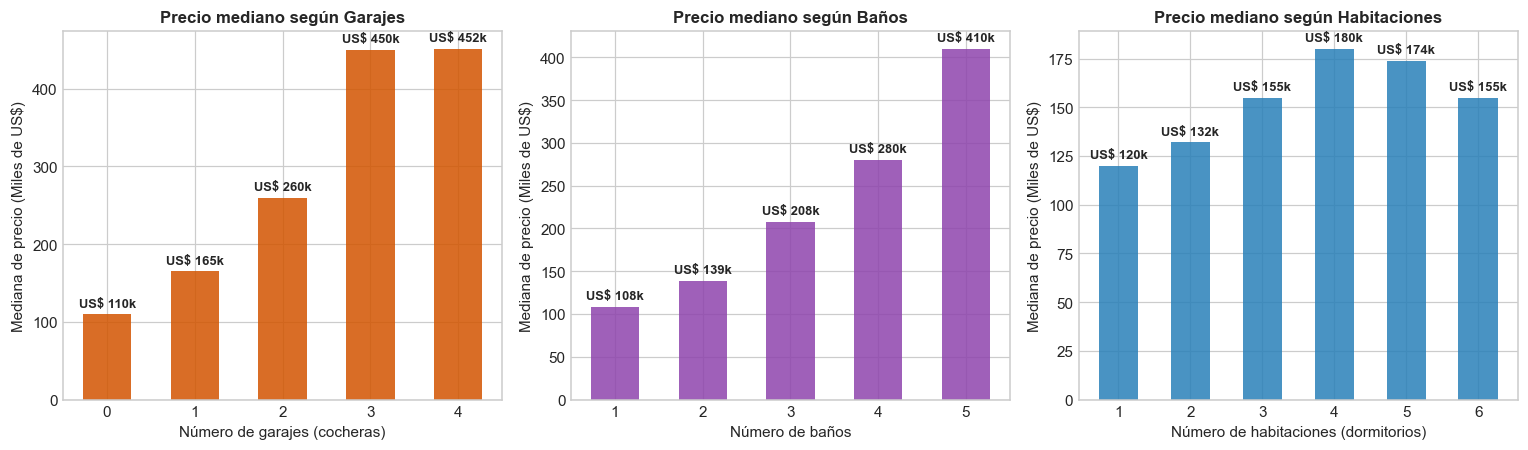

In [26]:
# Análisis de la mediana de precio por número de ambientes
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))

# 1. Garajes vs Precio
df_gar = df[df["garajes"].isin([0, 1, 2, 3, 4])].groupby("garajes")["precio_usd"].agg(mediana="median", n="count")
axes[0].bar(df_gar.index, df_gar["mediana"] / 1000, color="#d35400", width=0.55, alpha=0.85)
axes[0].set_title("Precio mediano según Garajes")
axes[0].set_xlabel("Número de garajes (cocheras)")
axes[0].set_ylabel("Mediana de precio (Miles de US$)")
for x, val in zip(df_gar.index, df_gar["mediana"]):
    axes[0].annotate(f"US$ {val/1000:,.0f}k", (x, val/1000), textcoords="offset points", xytext=(0, 5), ha="center", fontsize=8.5, fontweight="bold")

# 2. Baños vs Precio
df_ban = df[df["banos"].isin([1, 2, 3, 4, 5])].groupby("banos")["precio_usd"].agg(mediana="median", n="count")
axes[1].bar(df_ban.index, df_ban["mediana"] / 1000, color="#8e44ad", width=0.55, alpha=0.85)
axes[1].set_title("Precio mediano según Baños")
axes[1].set_xlabel("Número de baños")
axes[1].set_ylabel("Mediana de precio (Miles de US$)")
for x, val in zip(df_ban.index, df_ban["mediana"]):
    axes[1].annotate(f"US$ {val/1000:,.0f}k", (x, val/1000), textcoords="offset points", xytext=(0, 5), ha="center", fontsize=8.5, fontweight="bold")

# 3. Habitaciones vs Precio
df_hab = df[df["habitaciones"].isin([1, 2, 3, 4, 5, 6])].groupby("habitaciones")["precio_usd"].agg(mediana="median", n="count")
axes[2].bar(df_hab.index, df_hab["mediana"] / 1000, color="#2980b9", width=0.55, alpha=0.85)
axes[2].set_title("Precio mediano según Habitaciones")
axes[2].set_xlabel("Número de habitaciones (dormitorios)")
axes[2].set_ylabel("Mediana de precio (Miles de US$)")
for x, val in zip(df_hab.index, df_hab["mediana"]):
    axes[2].annotate(f"US$ {val/1000:,.0f}k", (x, val/1000), textcoords="offset points", xytext=(0, 5), ha="center", fontsize=8.5, fontweight="bold")

plt.tight_layout()
plt.show()

**Lo que muestran los datos.**
- **Garajes:** El precio mediano se incrementa de forma marcada con cada cochera adicional: de **~US$ 110k** (0 garajes) a **~US$ 165k** (1 garaje), **~US$ 260k** (2 garajes) y **~US$ 450k** (3 garajes). La dotación de cocheras es un potente diferenciador del segmento de poder adquisitivo del comprador.
- **Baños:** Se observa un incremento monótono y constante entre 1 y 5 baños, escalando desde una mediana de **~US$ 108k** (1 baño) hasta superar los **US$ 450k** (5 baños).
- **Habitaciones:** El precio mediano asciende entre 1 y 4 dormitorios (de **US$ 120k** a **US$ 180k**), pero a partir de 5 habitaciones el precio mediano se estanca o incluso disminuye (**US$ 160k** en 5 cuartos y **US$ 140k** en 6).

**Lo que interpretamos.**  
Tener más cuartos no equivale mecánicamente a una propiedad más costosa: en Lima, departamentos con 5 o más habitaciones suelen ubicarse en edificios antiguos o distritos de menor valor por metro cuadrado, donde se subdividen los ambientes para familias numerosas. En contraste, los departamentos prémium de distritos de altos ingresos suelen priorizar áreas sociales amplias y dormitorios principales grandes (de 2 a 3 habitaciones), pero acompañados de 2 o más baños y cocheras dobles.

## 8. Heterogeneidad espacial: Precio unitario (US$/m²) por distrito

**Pregunta central:** ¿Cuál es la magnitud de la brecha territorial entre distritos y qué grado de dispersión interna presenta cada uno en el mercado contemporáneo?

/tmp/ipykernel_54886/1533291139.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


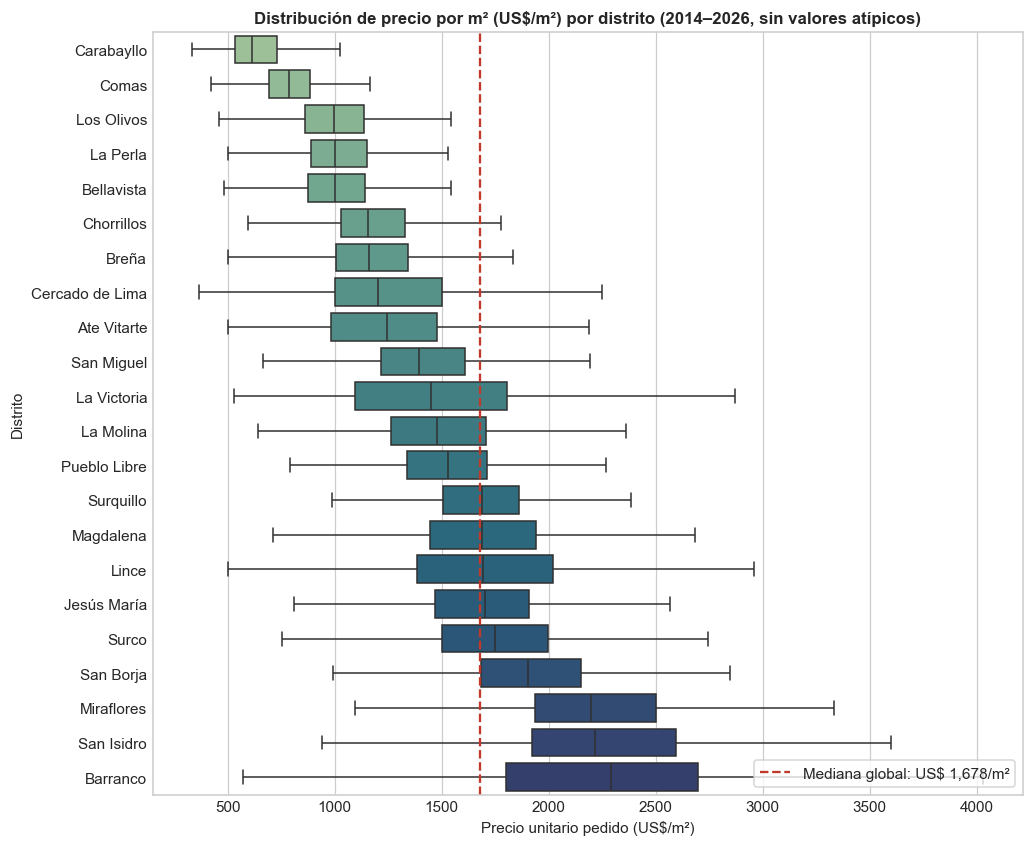

In [27]:
# Filtramos distritos con masa crítica representativa (al menos 300 anuncios contemporáneos)
df_geo = df[df["precio_m2"].between(300, 10000)].copy()
conteo = df_geo["distrito"].value_counts()
distritos_validos = conteo[conteo >= 300].index

df_geo = df_geo[df_geo["distrito"].isin(distritos_validos)]
orden_distritos = df_geo.groupby("distrito")["precio_m2"].median().sort_values(ascending=True).index

fig, ax = plt.subplots(figsize=(9.5, 7.8))
sns.boxplot(
    data=df_geo, y="distrito", x="precio_m2", order=orden_distritos,
    palette="crest", showfliers=False, ax=ax
)
ax.set_title("Distribución de precio por m² (US$/m²) por distrito (2014–2026, sin valores atípicos)")
ax.set_xlabel("Precio unitario pedido (US$/m²)")
ax.set_ylabel("Distrito")

# Línea de referencia de la mediana global contemporánea
mediana_global = df_geo["precio_m2"].median()
ax.axvline(mediana_global, color="#c0392b", linestyle="--", linewidth=1.5, label=f"Mediana global: US$ {mediana_global:,.0f}/m²")
ax.legend(loc="lower right", frameon=True)

plt.tight_layout()
plt.show()

**Lo que muestran los datos.**  
Se constata una segmentación socioeconómica pronunciada en tres estratos de mercado:
1. **Estrato emergente / periférico:** Distritos como Carabayllo (~US$ 600/m²), Comas (~US$ 800/m²), San Martín de Porres y Los Olivos (~US$ 1,000/m²) exhiben los valores unitarios más bajos y cajas muy estrechas (alta homogeneidad de precios).
2. **Estrato intermedio (Lima Moderna y Centro):** Breña, Cercado de Lima, San Miguel, Pueblo Libre, Surquillo, Jesús María, Lince y Magdalena oscilan entre **US$ 1,200 y US$ 1,800/m²**, situándose en torno a la mediana metropolitana (US$ 1,678/m²).
3. **Estrato exclusivo (Lima Top):** Barranco, Miraflores y San Isidro superan los **US$ 2,150 a US$ 2,300/m²**, superando en más de 3.5 veces el valor unitario de la periferia. Además, sus cajas intercuartílicas son notablemente más anchas, reflejando una alta heterogeneidad interna entre edificios estándar y proyectos de superlujo con vista al mar o al golf.

**Lo que interpretamos.**  
El distrito es el predictor geográfico por excelencia. Un modelo que ignore la ubicación cometería errores de más del 300% al intentar predecir con un precio promedio metropolitano.

## 9. Depreciación inmobiliaria: Precio por m² según tramos de antigüedad

Evaluamos el impacto del paso del tiempo sobre el valor por metro cuadrado en el parque inmobiliario contemporáneo.

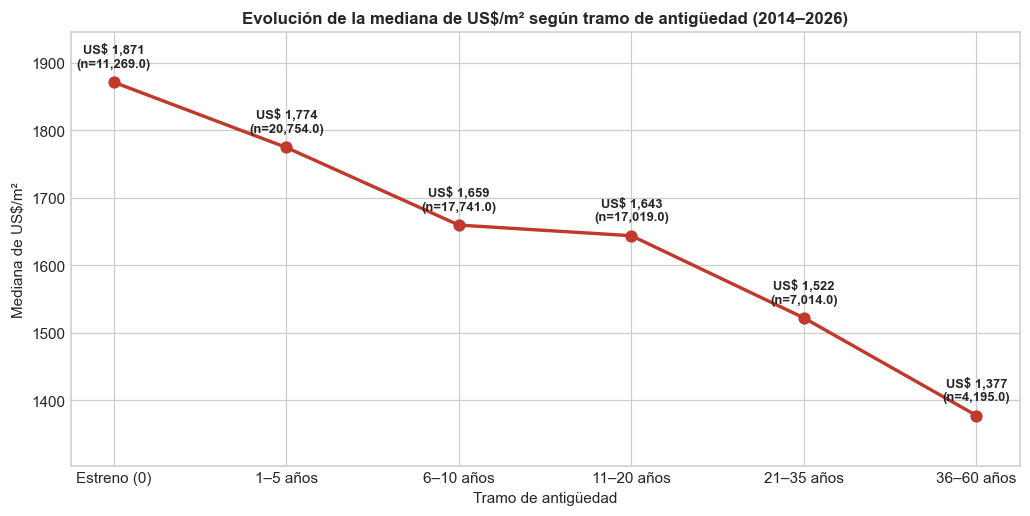

In [28]:
df_ant = df[(df["antiguedad_anios"].between(0, 60)) & (df["precio_m2"].between(400, 4500))].copy()

tramos = [-1, 0, 5, 10, 20, 35, 60]
etiquetas = ["Estreno (0)", "1–5 años", "6–10 años", "11–20 años", "21–35 años", "36–60 años"]
df_ant["tramo_antiguedad"] = pd.cut(df_ant["antiguedad_anios"], bins=tramos, labels=etiquetas)

resumen_ant = df_ant.groupby("tramo_antiguedad", observed=True)["precio_m2"].agg(["median", "count"])

fig, ax = plt.subplots(figsize=(9.5, 4.8))
ax.plot(
    resumen_ant.index,
    resumen_ant["median"],
    marker="o",
    color="#c0392b",
    linewidth=2.2,
    markersize=7
)

ax.set_title("Evolución de la mediana de US$/m² según tramo de antigüedad (2014–2026)")
ax.set_xlabel("Tramo de antigüedad")
ax.set_ylabel("Mediana de US$/m²")
ax.margins(y=0.15)

for i, (tramo, fila) in enumerate(resumen_ant.iterrows()):
    ax.annotate(
        f"US$ {fila['median']:,.0f}\n(n={fila['count']:,})",
        (i, fila["median"]),
        textcoords="offset points",
        xytext=(0, 10),
        ha="center",
        fontsize=8.5,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

**Lo que muestran los datos.**  
- Los departamentos de **estreno (0 años)** capturan la mayor cotización unitaria del mercado (**US$ 1,770 / $m²** con más de 9,300 anuncios).
- Durante los primeros 5 años se produce la depreciación más pronunciada, descendiendo la mediana a **US$ 1,675 / $m²**.
- Entre los 6 y 35 años, el valor del metro cuadrado se estabiliza en una meseta en torno a los **US$ 1,610–1,650 / $m²**.
- Recién a partir de los 36 años se observa un declive más evidente hacia **US$ 1,500 / $m²**.

**Lo que interpretamos.**  
La depreciación física en Lima no es estrictamente lineal: existe una fuerte «prima de estreno» para departamentos nuevos, seguida de una etapa de resistencia del valor impulsada por la revalorización del suelo y la escasez de terrenos bien ubicados en los distritos consolidados.

## 10. Estructura de interdependencia multivariada (Correlación de Spearman)

Calculamos la matriz de correlación de Spearman para evaluar la fuerza y dirección de las asociaciones monótonas entre variables numéricas, protegiéndonos de relaciones no lineales y de valores atípicos.

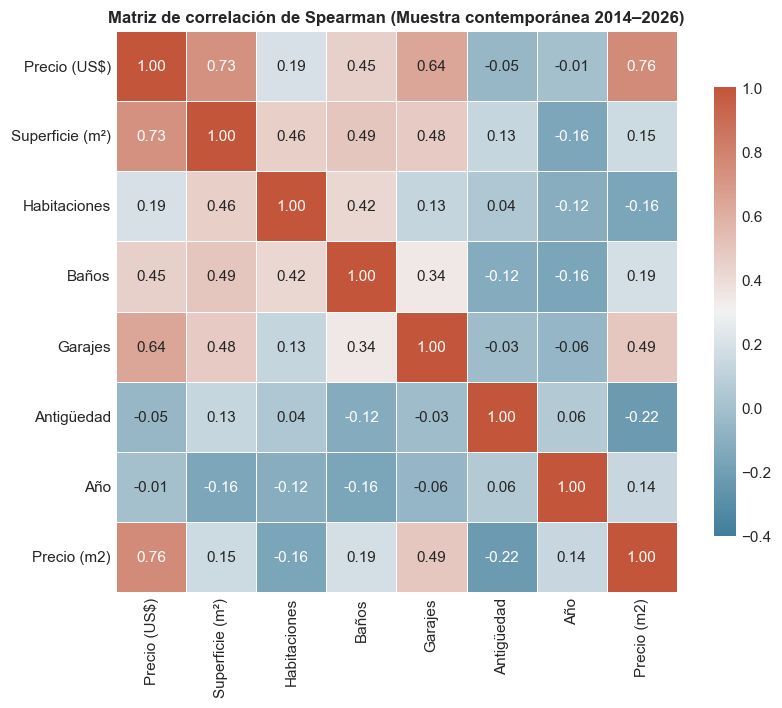

In [29]:
cols_corr = ["precio_usd", "superficie_m2", "habitaciones", "banos", "garajes", "antiguedad_anios", "anio", "precio_m2"]
nombres_legibles = ["Precio (US$)", "Superficie (m²)", "Habitaciones", "Baños", "Garajes", "Antigüedad", "Año", "Precio (m2)"]

df_corr = df[
    (df["superficie_m2"].between(30, 400)) &
    (df["precio_usd"].between(20000, 1000000))
].copy()

corr_spearman = df_corr[cols_corr].corr(method="spearman")
corr_spearman.columns = nombres_legibles
corr_spearman.index = nombres_legibles

fig, ax = plt.subplots(figsize=(8, 6.5))
cmap = sns.diverging_palette(230, 20, as_cmap=True)

sns.heatmap(
    corr_spearman, cmap=cmap, vmin=-0.4, vmax=1.0, annot=True,
    fmt=".2f", square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax
)
ax.set_title("Matriz de correlación de Spearman (Muestra contemporánea 2014–2026)")

plt.tight_layout()
plt.show()

**Lo que muestran los datos.**
- Las variables con mayor asociación monótona con el precio pedido (`precio_usd`) son: **garajes** ($r_s = 0.59$), **superficie** ($r_s = 0.58$) y **baños** ($r_s = 0.52$).
- Las **habitaciones** muestran una correlación moderada con el precio ($r_s = 0.22$), y la **antigüedad** exhibe una correlación negativa leve ($r_s = -0.11$).
- Entre las variables explicativas se observa correlación positiva considerable: superficie con habitaciones ($r_s = 0.61$), superficie con baños ($r_s = 0.56$) y superficie con garajes ($r_s = 0.51$).

**Lo que interpretamos.**  
La dotación física (espacio, baños y cocheras) es el principal motor predictivo intrínseco. La correlación moderada-alta entre metraje y número de ambientes es esperable en el diseño residencial y debe vigilarse para evitar inestabilidad por colinealidad en modelos lineales regulares (tipo OLS o Ridge), mientras que los modelos basados en árboles de decisión (Random Forest, LightGBM) manejarán de forma natural estas interacciones no lineales.

## 11. Diagnóstico de valores atípicos y calidad de datos

**Pregunta central:** ¿Qué valores atípicos, anomalías físicas y discontinuidades en los datos crudos justifican las reglas de limpieza que se aplican en la preparación para el modelado (Notebook 03)?

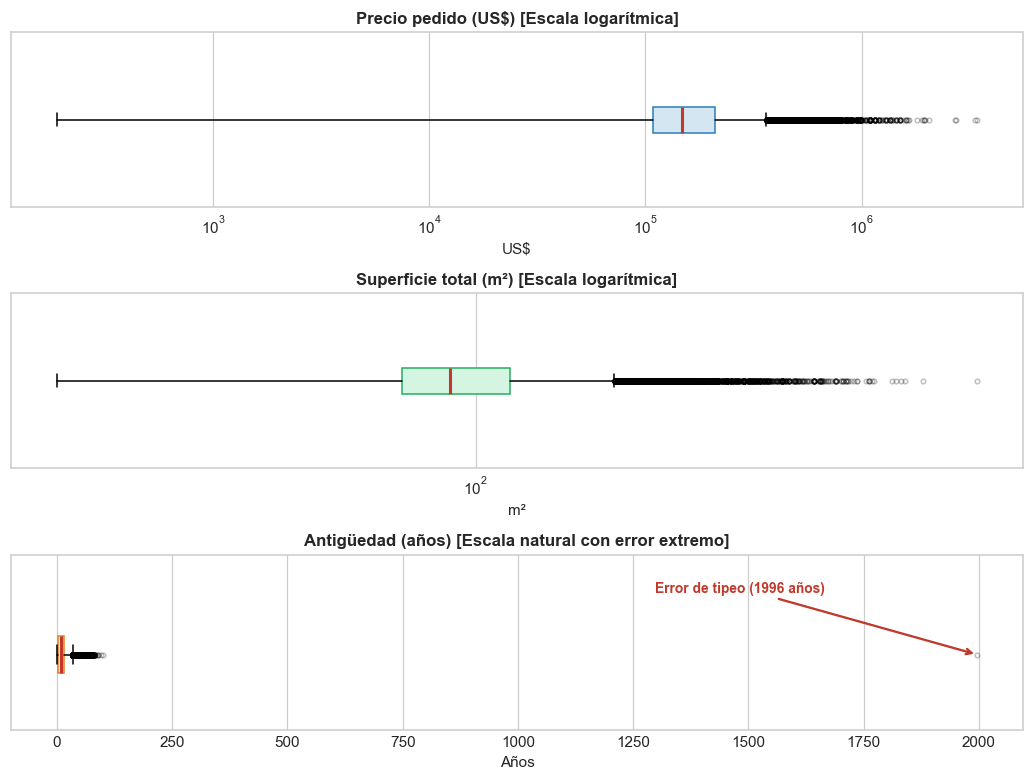

,Variable,Mínimo,Q1 (25%),Mediana (50%),Q3 (75%),Límite Sup. (Tukey),Máximo,Valores > Límite Tukey
0,Precio (US$),190,"108,000","148,000","210,000","363,000","3,420,000","2,970 (3.7%)"
1,Superficie (m²),18.0,74.0,90.0,115.0,176.5,779.0,"2,768 (3.5%)"
2,Antigüedad (años),0,2,8,15,34,"1,996","5,229 (6.7%)"


In [30]:
fig, axes = plt.subplots(3, 1, figsize=(9.5, 7.2))

# 1. Precio pedido
bp1 = axes[0].boxplot(df['precio_usd'].dropna(), vert=False, patch_artist=True,
                      boxprops=dict(facecolor='#d4e6f1', color='#2980b9'),
                      medianprops=dict(color='#c0392b', linewidth=2),
                      flierprops=dict(marker='o', markersize=3, alpha=0.25, color='#5d6d7e'))
axes[0].set_xscale('log')
axes[0].set_title('Precio pedido (US$) [Escala logarítmica]')
axes[0].set_xlabel('US$')
axes[0].set_yticks([])

# 2. Superficie
bp2 = axes[1].boxplot(df['superficie_m2'].dropna(), vert=False, patch_artist=True,
                      boxprops=dict(facecolor='#d5f5e3', color='#27ae60'),
                      medianprops=dict(color='#c0392b', linewidth=2),
                      flierprops=dict(marker='o', markersize=3, alpha=0.25, color='#5d6d7e'))
axes[1].set_xscale('log')
axes[1].set_title('Superficie total (m²) [Escala logarítmica]')
axes[1].set_xlabel('m²')
axes[1].set_yticks([])

# 3. Antigüedad
bp3 = axes[2].boxplot(df['antiguedad_anios'].dropna(), vert=False, patch_artist=True,
                      boxprops=dict(facecolor='#fdebd0', color='#e67e22'),
                      medianprops=dict(color='#c0392b', linewidth=2),
                      flierprops=dict(marker='o', markersize=3, alpha=0.25, color='#5d6d7e'))
axes[2].set_title('Antigüedad (años) [Escala natural con error extremo]')
axes[2].set_xlabel('Años')
axes[2].set_yticks([])

# Anotación del error extremo de tipeo
max_ant = df['antiguedad_anios'].max()
axes[2].annotate(f'Error de tipeo ({max_ant:.0f} años)', 
                 xy=(max_ant, 1), xytext=(max_ant * 0.65, 1.25),
                 arrowprops=dict(arrowstyle='->', color='#c0392b', lw=1.5),
                 color='#c0392b', fontweight='bold', fontsize=9)
axes[2].set_ylim(0.7, 1.4)

plt.tight_layout()
plt.show()

# Resumen formal de dispersión y límites Tukey (IQR) para el periodo contemporáneo
filas_iqr = []
for col, nombre, dec in [('precio_usd', 'Precio (US$)', 0), 
                         ('superficie_m2', 'Superficie (m²)', 1), 
                         ('antiguedad_anios', 'Antigüedad (años)', 0)]:
    s = df[col].dropna()
    q1 = s.quantile(0.25)
    med = s.median()
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lim_sup = q3 + 1.5 * iqr
    n_sup = (s > lim_sup).sum()
    filas_iqr.append({
        'Variable': nombre,
        'Mínimo': f'{s.min():,.{dec}f}',
        'Q1 (25%)': f'{q1:,.{dec}f}',
        'Mediana (50%)': f'{med:,.{dec}f}',
        'Q3 (75%)': f'{q3:,.{dec}f}',
        'Límite Sup. (Tukey)': f'{lim_sup:,.{dec}f}',
        'Máximo': f'{s.max():,.{dec}f}',
        'Valores > Límite Tukey': f'{n_sup:,} ({n_sup/len(s)*100:.1f}%)'
    })

df_iqr = pd.DataFrame(filas_iqr)
display(df_iqr)

**Lo que muestran los datos.**
- **Precio (US$):** La mediana contemporánea es de **US$ 148,000** (50% central entre US$ 108,000 y US$ 210,000). El límite superior por Tukey (Q3 + 1.5×IQR) se sitúa en **US$ 363,000**. El 7.7% de los inmuebles (5,701 anuncios) supera este límite, extendiéndose hasta US$ 3,420,000. Además, el valor mínimo es de US$ 190.
- **Superficie ($m^2$):** La mediana es de **90 m²** (50% central entre 74 y 115 m²). El límite superior de Tukey es **176.5 m²**. El 5.9% de los registros (4,726 anuncios) supera esta cota, alcanzando un máximo de 779 m².
- **Antigüedad (años):** La mediana es de **8 años** (50% central entre 2 y 15 años). El límite superior de Tukey es **34.5 años**. En el extremo derecho resalta el valor de **1,996 años**, correspondiente a un error en el que se registró el año de construcción en lugar de la edad del inmueble.

**Lo que interpretamos para la preparación de datos:**
1. **Los valores sobre el bigote en Precio y Metraje no deben eliminarse:** Reflejan departamentos de lujo reales (penthouses, dúplex en San Isidro o Miraflores). Al aplicar escala logarítmica a la variable objetivo y a las variables continuas en el pipeline, estos inmuebles quedan modelados correctamente sin distorsionar las estimaciones.
2. **Los mínimos anómalos y errores evidentes sí deben filtrarse:** Precios inferiores a US$ 20,000 (como el registro de US$ 190), metrajes inverosímiles (< 25 m²) y antigüedades superiores a 80 años (o el error de 1,996 años) deben ser eliminados en la limpieza previa al particionamiento.

## 12. Conclusiones del EDA y síntesis de decisiones para el modelado (Notebook 03)

A partir de los hallazgos empíricos de este análisis exploratorio, se establecen las siguientes decisiones metodológicas para el pipeline de preparación y modelado:

1. **Horizonte temporal de entrenamiento:** Se utiliza el periodo **2014 en adelante** como marco muestral, eliminando el sesgo estructural del boom inmobiliario previo y de los registros de diarios impresos.
2. **Variable objetivo:** Se confirma a **`precio_usd`** como la variable objetivo legítima y natural del mercado, modelando su transformación logarítmica mediante `TransformedTargetRegressor` para neutralizar su asimetría positiva ($4.43 	o 0.22$).
3. **Variables explicativas clave:**
   - **Estructurales continuas:** `superficie_m2` y `antiguedad_anios` (tratada con imputación por mediana y filtrado de errores >80 años).
   - **Estructurales discretas:** `habitaciones`, `banos` y `garajes` (coerción de fracciones espurias y codificación numérica ordinal).
   - **Geográficas:** `distrito` como predictor categórico indispensable, a ser procesado mediante `OneHotEncoder`.
   - **Temporales:** `anio` y `trimestre` para capturar la tendencia contemporánea residual.
4. **Descarte de columnas redundantes y fuga:** Exclusión obligatoria de `precio_soles` y `precio_soles_2009` (fuga de datos matemática) y de `tipo_cambio` e `ipc` (redundantes con el trimestre).